In [14]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

In [15]:
# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv('../data/raw/telco_churn_100k.csv')

# Standardize column names (lowercase + clean format)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Preview data
df.head()

,customerid,age,gender,tenure,monthlycharges,contract,paymentmethod,totalcharges,churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [16]:
# =========================================
# 3. DATA OVERVIEW
# =========================================
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   customerid      100000 non-null  int64  
 1   age             100000 non-null  int64  
 2   gender          100000 non-null  object 
 3   tenure          100000 non-null  int64  
 4   monthlycharges  100000 non-null  float64
 5   contract        100000 non-null  object 
 6   paymentmethod   100000 non-null  object 
 7   totalcharges    100000 non-null  float64
 8   churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


customerid        0
age               0
gender            0
tenure            0
monthlycharges    0
contract          0
paymentmethod     0
totalcharges      0
churn             0
dtype: int64

In [17]:
# =========================================
# 4. DATA CLEANING
# =========================================

# Convert churn to binary (Yes=1, No=0)
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

# Validate conversion
print(df['churn'].value_counts(normalize=True) * 100)

churn
0    66.856
1    33.144
Name: proportion, dtype: float64


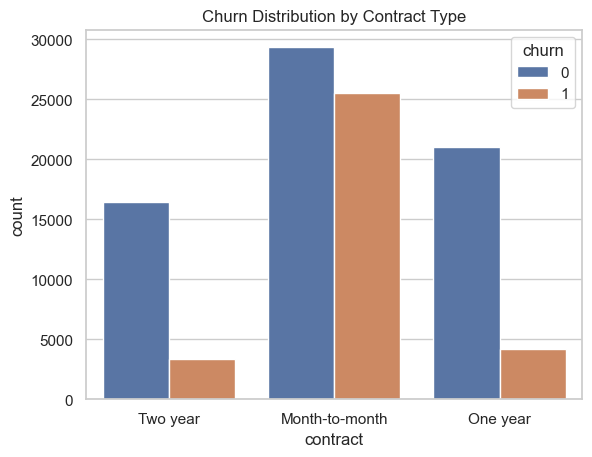

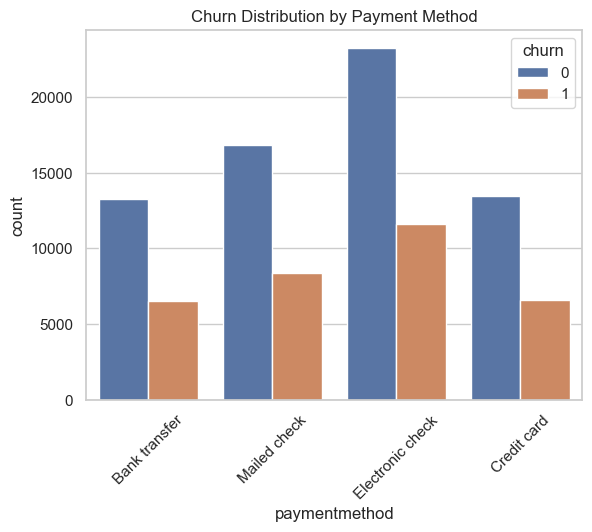

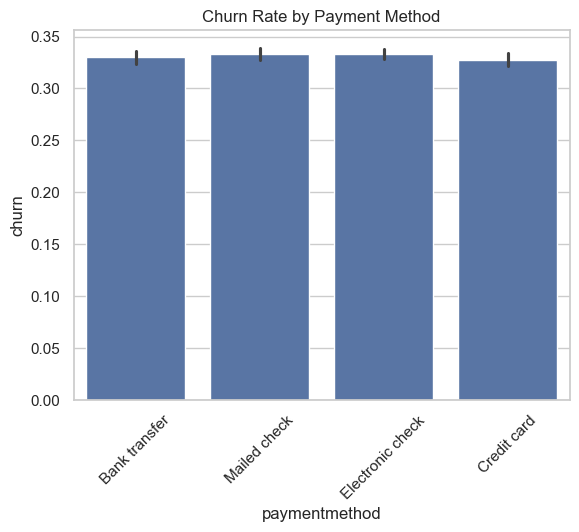

P-value (Payment Method vs Churn): 0.5665850894445632


In [18]:
# =========================================
# 5. CATEGORICAL ANALYSIS
# =========================================

# -----------------------------------------
# Churn distribution by Contract Type
# -----------------------------------------
sns.countplot(data=df, x='contract', hue='churn')
plt.title('Churn Distribution by Contract Type')
plt.show()


# -----------------------------------------
# Churn distribution by Payment Method
# -----------------------------------------
sns.countplot(data=df, x='paymentmethod', hue='churn')
plt.title("Churn Distribution by Payment Method")
plt.xticks(rotation=45)
plt.show()


# -----------------------------------------
# Churn Rate by Payment Method (INSIGHT)
# -----------------------------------------
sns.barplot(data=df, x='paymentmethod', y='churn')
plt.xticks(rotation=45)
plt.title("Churn Rate by Payment Method")
plt.show()


# -----------------------------------------
# Statistical Test (Chi-Square)
# -----------------------------------------
from scipy.stats import chi2_contingency

cont = pd.crosstab(df['paymentmethod'], df['churn'])
chi2, p, _, _ = chi2_contingency(cont)

print("P-value (Payment Method vs Churn):", p)

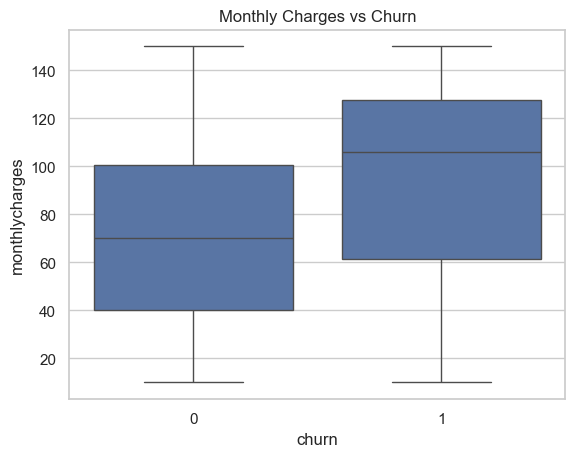

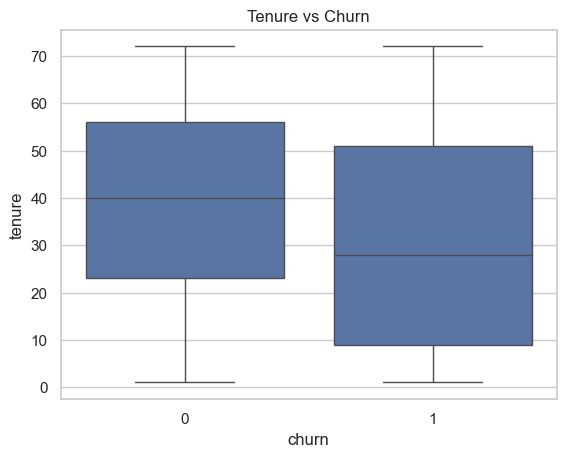

In [19]:

# =========================================
# 6. NUMERICAL ANALYSIS
# =========================================

# -----------------------------------------
# Monthly Charges vs Churn
# -----------------------------------------
sns.boxplot(data=df, x='churn', y='monthlycharges')
plt.title('Monthly Charges vs Churn')
plt.show()


# -----------------------------------------
# Tenure vs Churn
# -----------------------------------------
sns.boxplot(data=df, x='churn', y='tenure')
plt.title('Tenure vs Churn')
plt.show()

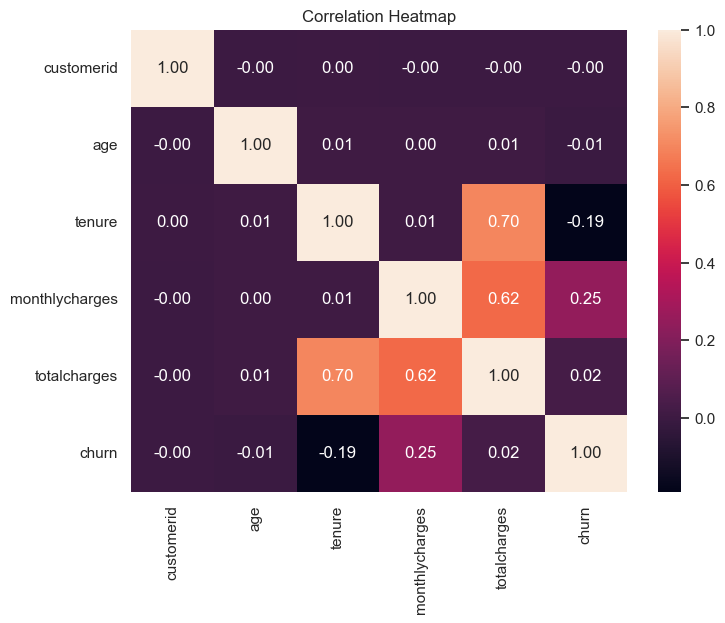

In [20]:
# =========================================
# 7. CORRELATION ANALYSIS
# =========================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [21]:


# =========================================
# 8. CONTRACT ANALYSIS (KEY BUSINESS INSIGHT)
# =========================================

# Chi-square test for Contract vs Churn
contingency = pd.crosstab(df['contract'], df['churn'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi2 (Contract vs Churn):", chi2)
print("P-value (Contract vs Churn):", p)


# -----------------------------------------
# Churn rate by Contract Type
# -----------------------------------------
churn_rates = pd.crosstab(df['contract'], df['churn'], normalize='index')
print(churn_rates)

Chi2 (Contract vs Churn): 9889.981708220985
P-value (Contract vs Churn): 0.0
churn                  0         1
contract                          
Month-to-month  0.534426  0.465574
One year        0.832509  0.167491
Two year        0.831215  0.168785
